# RAG Basics

### Retrieval-Augmented Generation (RAG) is a technique used in Large Language Models (LLMs) to improve their ability to generate high-quality text that is similar to the input text. RAG combines the strengths of two existing techniques: **Retrieval** and **Generation**.

In traditional LLMs, generation refers to predicting the next word or token based on the context and the model's internal state. This process is often iterative, where the model predicts one token at a time, refining its understanding of the input text as it generates new text.

Retrieval, on the other hand, involves searching for relevant sentences or fragments from a large corpus that match the input text. This can help the model learn to generate more coherent and accurate text by incorporating knowledge from the retrieved texts.

**How does RAG work?**

RAG combines these two techniques in a single pass:

1. **Retrieval**: The input text is searched against a large corpus, such as a database of sentences or documents, to retrieve relevant snippets that are similar in meaning or content.
2. **Generation**: The retrieved snippets are used as input to generate new text, which is then combined with the original input text.


## Parse a PDF

In [2]:
import pdfplumber
import random

In [3]:
# Function to load and extract text from the PDF, while collecting metadata
def extract_text_from_pdf(pdf_path):
    print(f"[INFO] Extracting text from PDF: {pdf_path}")
    
    # Initialize metadata
    metadata = {
        "total_pages": 0,
        "pages_with_text": 0,
        "total_characters": 0,
        "page_wise_text_stats": {}  # To store characters per page
    }
    
    with pdfplumber.open(pdf_path) as pdf:
        text = ""
        metadata["total_pages"] = len(pdf.pages)
        
        for page_num, page in enumerate(pdf.pages):
            page_text = page.extract_text()
            if page_text:
                text += page_text + "\n"
                metadata["pages_with_text"] += 1
                metadata["total_characters"] += len(page_text)
                metadata["page_wise_text_stats"][f"Page {page_num + 1}"] = len(page_text)
            else:
                print(f"[WARNING] No text found on page {page_num}.")
    
    # Print the first 500 characters as an example of the extracted text
    print(f"\n[INFO] Example of extracted text (first 500 characters):\n{text[:500]}")
    
    # Print metadata summary
    print(f"\n[INFO] Metadata Summary:")
    print(f"Total Pages: {metadata['total_pages']}")
    print(f"Pages with Text: {metadata['pages_with_text']}")
    print(f"Total Characters Extracted: {metadata['total_characters']}")
    
    return text, metadata


In [4]:
# Function to print a random section of a given number of words
def print_random_section_of_words(text, num_words):
    words = text.split()  # Split text into words
    total_words = len(words)
    
    if total_words < num_words:
        print(f"\n[WARNING] Not enough words in the text to print {num_words} words.")
        print(f"Full Text: {' '.join(words)}")
    else:
        random_start = random.randint(0, total_words - num_words)  # Pick a random starting point
        random_section = words[random_start:random_start + num_words]  # Select the section
        print(f"\n[INFO] Random Section of {num_words} Words:\n{' '.join(random_section)}")


In [5]:
# Path to the PDF file
pdf_path = '/m2-data/pdfs/Hitchhikersguidetothegalaxy.pdf'

# Step 1: Extract text from the PDF with metadata and print a random section
extracted_text, parsing_metadata = extract_text_from_pdf(pdf_path)

# Ensure that text has been extracted
if extracted_text:
    print("[INFO] Text extracted successfully.")
    print_random_section_of_words(extracted_text, 100)
else:
    print("[ERROR] Text extraction failed.")


[INFO] Extracting text from PDF: /m2-data/pdfs/Hitchhikersguidetothegalaxy.pdf

[INFO] Example of extracted text (first 500 characters):
The Hitchhiker’s Guide to the Galaxy
Douglas Adams
for Jonny Brock and Clare Gorst
and all other Arlingtonians for
tea, sympathy and a sofa
Far out in the uncharted backwaters of the unfashionable end of the west-
ern spiral arm of the Galaxy lies a small unregarded yellow sun. Orbiting
this at a distance of roughly ninety-two million miles is an utterly insignifi-
cant little blue green planet whose ape-descended life forms are so amazingly
primitive that they still think digital watches are a 

[INFO] Metadata Summary:
Total Pages: 144
Pages with Text: 144
Total Characters Extracted: 267546
[INFO] Text extracted successfully.

[INFO] Random Section of 100 Words:
at the ceiling – ”except some of the shouting I quite like.” He filled his lungs and bellowed, ”Resistance is ...” ”Sure, yes,” interrupted Ford hurriedly, ”you’re good at that, I can tell. 

## Chunking the text
### Split the text into 500 word chunks
### Will be used to generate embeddings

In [6]:
# Step 2: Function to chunk the extracted text into manageable chunks
def chunk_text(text, chunk_size=500):
    print(f"[INFO] Chunking text into chunks of size {chunk_size} words...")
    
    # Split the text into words
    words = text.split()
    
    # Create chunks of 'chunk_size' words
    chunks = []
    for i in range(0, len(words), chunk_size):
        chunk = " ".join(words[i:i + chunk_size])
        chunks.append(chunk)
    
    # Print the number of chunks created and an example chunk
    print(f"[INFO] Total Chunks Created: {len(chunks)}")
    print(f"\n[INFO] Example Chunk (first chunk, first 500 characters):\n{chunks[0][:500]}")
    
    return chunks


In [7]:
# Ensure the text was successfully extracted before chunking
if 'extracted_text' in globals() and extracted_text:
    chunk_size = 500  # Define the chunk size in words
    chunks = chunk_text(extracted_text, chunk_size)
else:
    print("[ERROR] Cannot chunk text because extraction failed or 'extracted_text' is undefined.")


[INFO] Chunking text into chunks of size 500 words...
[INFO] Total Chunks Created: 92

[INFO] Example Chunk (first chunk, first 500 characters):
The Hitchhiker’s Guide to the Galaxy Douglas Adams for Jonny Brock and Clare Gorst and all other Arlingtonians for tea, sympathy and a sofa Far out in the uncharted backwaters of the unfashionable end of the west- ern spiral arm of the Galaxy lies a small unregarded yellow sun. Orbiting this at a distance of roughly ninety-two million miles is an utterly insignifi- cant little blue green planet whose ape-descended life forms are so amazingly primitive that they still think digital watches are a 


## Generate Embeddings

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer

In [9]:
# Load the pre-trained SentenceTransformer model
def load_embedding_model():
    print("[INFO] Loading pre-trained SentenceTransformer model...")
    model = SentenceTransformer('all-MiniLM-L6-v2')
    return model

# Function to generate embeddings for each chunk
def generate_embeddings(chunks, model):
    print(f"[INFO] Generating embeddings for {len(chunks)} chunks...")
    
    # Generate embeddings for each chunk and store them
    embeddings = []
    for chunk in chunks:
        embedding = model.encode(chunk)
        embeddings.append(embedding)
    
    # Convert embeddings to a NumPy array for easier handling
    embeddings = np.array(embeddings)

    # Print the shape of the embeddings (number of chunks and size of each embedding)
    print(f"[INFO] Embedding Matrix Shape: {embeddings.shape}")
    
    # Print the first 10 values of the first embedding to visualize it
    print(f"\n[INFO] Example Embedding (first 10 values of the first chunk):\n{embeddings[0][:10]}")

    return embeddings

# Function to visualize a single embedding vector (first 10 dimensions)
def visualize_embedding(embedding):
    print("[INFO] Visualizing the first 10 dimensions of an example embedding...")
    
    # Plot the first 10 dimensions
    plt.figure(figsize=(10, 6))
    plt.plot(embedding[:10], marker='o')
    plt.title("Visualization of First 10 Dimensions of an Embedding")
    plt.xlabel("Dimension Index")
    plt.ylabel("Value")
    plt.grid(True)
    plt.show()


## Generate and Visualize Embeddings

[INFO] Loading pre-trained SentenceTransformer model...


/m2-data/pythonEnvironments/gpu_env/lib/python3.11/site-packages/transformers/tokenization_utils_base.py:1601: FutureWarning: `clean_up_tokenization_spaces` was not set. It will be set to `True` by default. This behavior will be depracted in transformers v4.45, and will be then set to `False` by default. For more details check this issue: https://github.com/huggingface/transformers/issues/31884
  warnings.warn(


[INFO] Generating embeddings for 92 chunks...
[INFO] Embedding Matrix Shape: (92, 384)

[INFO] Example Embedding (first 10 values of the first chunk):
[-0.02480139  0.07332658  0.08734293  0.00402481  0.10042586 -0.02066616
 -0.01927524  0.06220718  0.05969967  0.10143454]
[INFO] Visualizing the first 10 dimensions of an example embedding...


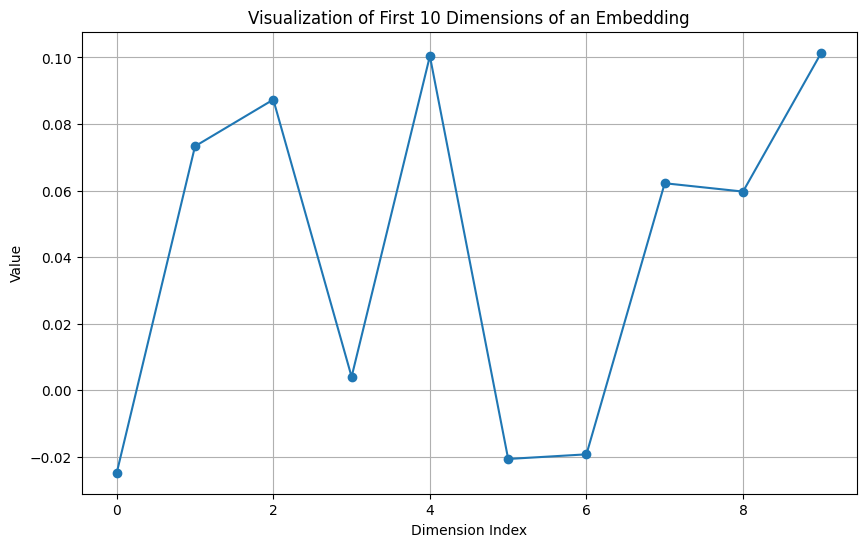

Each number in the embedding vector is a dimension in a high-dimensional space and together the dimensions form a "signature" for that text.
value on the Y-axis shows how important a particular feature (or aspect) of the text chunk is in that dimension.
Showing 10 of 384 dimesions


In [10]:
# Ensure that chunks have been created before generating embeddings
if 'chunks' in globals() and chunks:
    # Load the SentenceTransformer model
    embedding_model = load_embedding_model()
    
    # Generate embeddings for the chunks
    embeddings = generate_embeddings(chunks, embedding_model)
    
    # Visualize the first embedding (first 10 dimensions)
    visualize_embedding(embeddings[0])
else:
    print("[ERROR] Cannot generate embeddings because 'chunks' is undefined.")

print('Each number in the embedding vector is a dimension in a high-dimensional space and \
together the dimensions form a "signature" for that text.')
print('value on the Y-axis shows how important a particular feature (or aspect) of the text chunk is in that dimension.')
print('Showing 10 of 384 dimesions')

## Store Embeddings in FAISS Index

In [11]:
import faiss
import numpy as np

# Function to store embeddings in a FAISS index
def store_embeddings_in_faiss(embeddings):
    print("[INFO] Storing embeddings in FAISS index...")

    # Get the dimension of the embedding vectors
    dimension = embeddings.shape[1]
    
    # Create a FAISS index using L2 distance (can be changed to cosine similarity if needed)
    index = faiss.IndexFlatL2(dimension)
    
    # Add embeddings to the index
    index.add(embeddings)
    
    # Print a summary of the index
    print(f"[INFO] FAISS index has been created with {index.ntotal} embeddings.")
    
    return index

# Ensure that embeddings have been generated before storing them in FAISS
if 'embeddings' in globals() and embeddings is not None:
    # Store the embeddings in FAISS
    faiss_index = store_embeddings_in_faiss(embeddings)
else:
    print("[ERROR] Cannot store embeddings because 'embeddings' is undefined.")


[INFO] Storing embeddings in FAISS index...
[INFO] FAISS index has been created with 92 embeddings.


## User Query and Search
###   and 
## Query LLM for Final Response

### tinyllama

In [12]:
import requests
import json
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer

# Load the embedding model (if not loaded already)
embedding_model = SentenceTransformer('all-MiniLM-L6-v2')

# Example FAISS retrieval results - limit to top 2 chunks for simplicity
retrieved_chunks = ["Chunk 1 sample text...", "Chunk 2 sample text..."]

# Function to send the prompt to the LLM (TinyLlama) using the Ollama API
def query_ollama_llm(prompt, model_name="tinyllama", temperature=0.7):
    url = "http://localhost:11434/api/generate"
    
    payload = {
        "model": model_name,
        "prompt": prompt,
        "temperature": temperature  # Adding temperature to the payload
    }
    
    response = requests.post(url, json=payload, stream=True)
    
    if response.status_code != 200:
        raise Exception(f"Failed to query {model_name}: {response.status_code}, {response.text}")
    
    full_response = ""
    for line in response.iter_lines():
        if line:
            try:
                json_line = line.decode('utf-8')
                data = json.loads(json_line)
                
                if "response" in data:
                    full_response += data["response"]
            except json.JSONDecodeError as e:
                print(f"Error parsing line: {e}")
    
    return full_response

# Function to create the prompt from retrieved chunks and user query
def create_prompt(user_query, retrieved_chunks):
    context = "\n\n".join(retrieved_chunks)  # Join the chunks into a single string
    prompt = f"Context:\n{context}\n\nQuestion: {user_query}\n\nAnswer:"
    return prompt

# Define the user query
user_query = "What is the question that the ultimate answer was in response to?"

# Ensure that chunks have been retrieved and the embedding model is available
if retrieved_chunks and embedding_model:
    # Create the query embedding
    query_embedding = embedding_model.encode(user_query)
    
    # Visualize the user query embedding
    visualize_embedding(query_embedding, title="User Query Embedding")
    
    # Create the prompt using the retrieved chunks and the user query
    prompt = create_prompt(user_query, retrieved_chunks)
    
    # Query TinyLlama with the prompt and temperature setting
    print("[INFO] Querying TinyLlama with temperature=0.7...")
    tinyllama_response = query_ollama_llm(prompt, model_name="tinyllama", temperature=0.7)
    print("\n[INFO] Response from TinyLlama:\n", tinyllama_response)
else:
    print("[ERROR] Retrieved chunks or embedding model are undefined or empty.")


TypeError: visualize_embedding() got an unexpected keyword argument 'title'

### llama3

In [13]:
import requests
import json
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer

# Load the embedding model (if not loaded already)
embedding_model = SentenceTransformer('all-MiniLM-L6-v2')

# Example FAISS retrieval results - using top 2 chunks for better context
retrieved_chunks = [
    "Chunk 1: In the book, the answer to the ultimate question of life, the universe, and everything is given as 42...",
    "Chunk 2: However, the actual question that led to this answer is never fully revealed..."
]

# Function to send the prompt to the LLM (Llama3) using the Ollama API
def query_ollama_llm(prompt, model_name="llama3", temperature=0.7):
    url = "http://localhost:11434/api/generate"
    
    payload = {
        "model": model_name,
        "prompt": prompt,
        "temperature": temperature  # Adding temperature to the payload
    }
    
    response = requests.post(url, json=payload, stream=True)
    
    if response.status_code != 200:
        raise Exception(f"Failed to query {model_name}: {response.status_code}, {response.text}")
    
    full_response = ""
    for line in response.iter_lines():
        if line:
            try:
                json_line = line.decode('utf-8')
                data = json.loads(json_line)
                
                if "response" in data:
                    full_response += data["response"]
            except json.JSONDecodeError as e:
                print(f"Error parsing line: {e}")
    
    return full_response

# Function to create the prompt from retrieved chunks and user query
def create_prompt_for_llama3(user_query, retrieved_chunks):
    # Join the chunks together for more context
    context = "\n\n".join(retrieved_chunks)
    
    # Updated prompt with more explicit instructions
    prompt = (f"Here is some context from the document:\n\n"
              f"{context}\n\n"
              f"Now, based on this context, answer the following question:\n\n"
              f"Question: {user_query}\n\n"
              "Answer:")
    
    return prompt

# Define the user query
user_query = "What is the question that the ultimate answer was in response to?"

# Ensure that chunks have been retrieved and the embedding model is available
if retrieved_chunks and embedding_model:
    # Create the query embedding
    query_embedding = embedding_model.encode(user_query)
    
    # Create the prompt using the retrieved chunks and the user query for Llama3
    prompt_llama3 = create_prompt_for_llama3(user_query, retrieved_chunks)
    
    # Query Llama3 with the prompt and temperature setting
    print("[INFO] Querying Llama3 with temperature=0.7...")
    llama3_response = query_ollama_llm(prompt_llama3, model_name="llama3", temperature=0.7)
    print("\n[INFO] Response from Llama3:\n", llama3_response)
else:
    print("[ERROR] Retrieved chunks or embedding model are undefined or empty.")


[INFO] Querying Llama3 with temperature=0.7...

[INFO] Response from Llama3:
 The answer, my friend, is "What is the question that the ultimate answer was in response to?"... just kidding!

Based on the provided context, it seems that the actual question that led to the answer 42 is never fully revealed. Therefore, we can't know what the question is.

According to the book, all we know is that the answer is given as 42, but the question itself remains a mystery.

So, my answer would be: "The question that the ultimate answer was in response to is unknown."


### temp 0.1

In [14]:
import requests
import json
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer

# Load the embedding model (if not loaded already)
embedding_model = SentenceTransformer('all-MiniLM-L6-v2')

# Example FAISS retrieval results - using top 2 chunks for better context
retrieved_chunks = [
    "Chunk 1: In the book, the answer to the ultimate question of life, the universe, and everything is given as 42...",
    "Chunk 2: However, the actual question that led to this answer is never fully revealed..."
]

# Function to send the prompt to the LLM (Llama3) using the Ollama API
def query_ollama_llm(prompt, model_name="llama3", temperature=0.7):
    url = "http://localhost:11434/api/generate"
    
    payload = {
        "model": model_name,
        "prompt": prompt,
        "temperature": temperature  # Adding temperature to the payload
    }
    
    response = requests.post(url, json=payload, stream=True)
    
    if response.status_code != 200:
        raise Exception(f"Failed to query {model_name}: {response.status_code}, {response.text}")
    
    full_response = ""
    for line in response.iter_lines():
        if line:
            try:
                json_line = line.decode('utf-8')
                data = json.loads(json_line)
                
                if "response" in data:
                    full_response += data["response"]
            except json.JSONDecodeError as e:
                print(f"Error parsing line: {e}")
    
    return full_response

# Function to create the prompt from retrieved chunks and user query
def create_prompt_for_llama3(user_query, retrieved_chunks):
    # Join the chunks together for more context
    context = "\n\n".join(retrieved_chunks)
    
    # Updated prompt with more explicit instructions
    prompt = (f"Here is some context from the document:\n\n"
              f"{context}\n\n"
              f"Now, based on this context, answer the following question:\n\n"
              f"Question: {user_query}\n\n"
              "Answer:")
    
    return prompt

# Define the user query
user_query = "What is the question that the ultimate answer was in response to?"

# Ensure that chunks have been retrieved and the embedding model is available
if retrieved_chunks and embedding_model:
    # Create the query embedding
    query_embedding = embedding_model.encode(user_query)
    
    # Create the prompt using the retrieved chunks and the user query for Llama3
    prompt_llama3 = create_prompt_for_llama3(user_query, retrieved_chunks)
    
    # Query Llama3 with the prompt and temperature setting
    print("[INFO] Querying Llama3 with temperature=0.1...")
    llama3_response = query_ollama_llm(prompt_llama3, model_name="llama3", temperature=0.1)
    print("\n[INFO] Response from Llama3:\n", llama3_response)
else:
    print("[ERROR] Retrieved chunks or embedding model are undefined or empty.")


[INFO] Querying Llama3 with temperature=0.1...

[INFO] Response from Llama3:
 A classic reference!

Based on the provided context, I'll take a stab at answering:

The question that the ultimate answer (42) was in response to is... unknown! According to Chunk 2, the actual question that led to this answer is never fully revealed. Therefore, we cannot determine what the question is that the ultimate answer of 42 was intended to answer.
